In [48]:
import numpy as np
import matplotlib.pyplot as plt

In [303]:
mass = 1.223   # solar mass
radius = 1.357   # solar radius
lum = mass**4   # solar lum
teff = 6325   # K
teff_sun = 5777   # K

In [304]:
# source: chaplin & miglio (2013)
def large_separation(mass, radius):
    del_nu_sun = 135.1   # micro Hz
    del_nu = del_nu_sun*(mass**(1/2))*(radius**(-3/2))
    return del_nu

In [305]:
# source: chaplin & miglio (2013)
def mode_max(mass, radius, teff, teff_sun):
    nu_max_sun = 3090   # micro Hz
    g = mass/(radius**2)
    nu_max = nu_max_sun*g*((teff/teff_sun)**(-1/2))
    #print('v_max', v_max)
    return nu_max

In [306]:
# source: lund et al (2016)
def mode_freq(mass, radius):
    order = [i for i in range(10,101)]
    degree = [i for i in range(0,4)]
    epsilon = 1.55
    del_nu = large_separation(mass, radius)
    D_0 = 0.01*del_nu
    # asymptotic relation

    modes = []
    for l in degree:
        for n in order:
            nu_nl = (n + l/2 + epsilon)*del_nu - l*(l + 1)*D_0
            modes.append((n, l, nu_nl))
    modes = np.array(modes, dtype=[("n", int), ("l", int), ("nu", float)])
    frequencies = modes["nu"]
    #print('v_nl for l=3, n=[10,100]', modes)
    return np.array(frequencies)

In [307]:
# source: ball et al (2018)
def amp_rms_max(mass, teff, teff_sun):
    tred = 8907*(lum)**(-0.093)
    del_T = 1250
    beta = 1-np.exp((teff-tred)/del_T)
    amp_max = 2.1*beta*lum*(1/mass)*((teff/teff_sun)**(-2))
    #print(f'tred={tred}, beta={beta}')
    #print('amp_rms_max', amp_max)
    return amp_max

In [308]:
# source: ball et al (2018)
# this is gamma_env, the width of the gaussian power envelope
# this is not the same as gamma or gamma_nl, the width of the individual modal peaks indicating damping
def fwhm_envelope(mass, radius, teff, teff_sun):
    nu_max = mode_max(mass, radius, teff, teff_sun)   # float
    fwhm_env = (0.66)*((nu_max)**0.88)   # float
    if teff>teff_sun:
        fwhm_env = (1 + 6e-4*(teff-teff_sun))*fwhm_env
    return fwhm_env   # float

In [309]:
# source: ball et al (2018)
def amp_rms_nl_square(mass, radius, teff, teff_sun):
    nu_max = mode_max(mass, radius, teff, teff_sun)   # float
    #print(f'v_max={v_max}')
    fwhm_env = fwhm_envelope(mass, radius, teff, teff_sun)   # float
    sig_env = fwhm_env/(2*np.sqrt(2*np.log(2)))   # float
    #print(f'fwhm={fwhm_env}, sig={sig_env}')
    nu_nl = mode_freq(mass, radius)   # array
    amp_max = amp_rms_max(mass, teff, teff_sun)   # float
    #print(f'amp_rms_max={amp_max}')
    amp_nl=(amp_max**2)*np.exp(-((nu_nl-nu_max)**2)/(2*(sig_env**2)))   # array

    #print(f'(amp_max**2)={(amp_max**2)}')
    #print(f'np.exp(-((v_nl-v_max)**2)/(2*(sig_env**2)))={np.exp(-((v_nl-v_max)**2)/(2*(sig_env**2)))}')
    #print(f'-((v_nl-v_max)**2)/(2*(sig_env**2))={-((v_nl-v_max)**2)/(2*(sig_env**2))}')
    #print('\namp_rms_nl', amp_nl)
    return amp_nl

In [310]:
print(amp_rms_nl_square(mass, radius, teff, teff_sun))

[8.05114748e-002 1.97768592e-001 4.38129052e-001 8.75370631e-001
 1.57734641e+000 2.56334689e+000 3.75692801e+000 4.96596384e+000
 5.91996888e+000 6.36473733e+000 6.17144320e+000 5.39682303e+000
 4.25632526e+000 3.02744757e+000 1.94206447e+000 1.12355890e+000
 5.86237014e-001 2.75864501e-001 1.17074845e-001 4.48101660e-002
 1.54680193e-002 4.81546298e-003 1.35203079e-003 3.42357861e-004
 7.81842397e-005 1.61028713e-005 2.99111158e-006 5.01080034e-007
 7.57053849e-008 1.03155321e-008 1.26765680e-009 1.40493727e-010
 1.40429183e-011 1.26591048e-012 1.02918585e-013 7.54622610e-015
 4.99012022e-016 2.97603061e-017 1.60069640e-018 7.76471885e-020
 3.39693855e-021 1.34027784e-022 4.76921798e-024 1.53054005e-025
 4.42983362e-027 1.15631277e-028 2.72212722e-030 5.77945259e-032
 1.10664973e-033 1.91107992e-035 2.97640967e-037 4.18072647e-039
 5.29609774e-041 6.05069720e-043 6.23447715e-045 5.79348445e-047
 4.85539810e-049 3.66990677e-051 2.50167225e-053 1.53798103e-055
 8.52740202e-058 4.264103

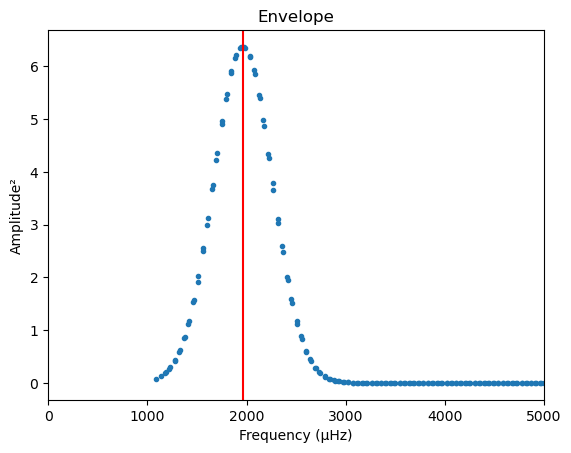

In [311]:
# CHECK: envelope
plt.plot(mode_freq(mass, radius), amp_rms_nl_square(mass, radius, teff, teff_sun), '.')
plt.axvline(mode_max(mass, radius, teff, teff_sun), color='r')
plt.xlabel("Frequency (μHz)")
plt.ylabel("Amplitude²")
plt.xlim(0,5000)
plt.title("Envelope")
plt.show()

In [312]:
# source: yang (2018)
def linewidths(mass, radius, teff, teff_sun):
    width_sun = 0.95   # micro Hz (baudin et al 2011)
    del_nu_ratio = (mass**(1/2))*(radius**(-3/2))
    # f_param is a free parameter in range 1-5, with mean of 3 (yang 2018)
    # this can be refined so f is actually a free parameter rather than fixed at its mean for simplicity
    f_param = 1
    if mass > 1.2:
        f_param = 3
    gamma = f_param*(mass*radius)*del_nu_ratio*((teff/teff_sun)**3)*width_sun
    return gamma

In [313]:
#A^2_rms=(pi/2)(H*gamma)
# source: chaplin & miglio (2013)
def height_nl(mass, radius, teff, teff_sun):
    amp_nl = amp_rms_nl_square(mass, radius, teff, teff_sun)   # array
    lw_nl = linewidths(mass, radius, teff, teff_sun)
    return 2*amp_nl/(np.pi*lw_nl)   # array

In [314]:
# source: spectrum basics
def power_spec(mass, radius, teff, teff_sun):
    height = height_nl(mass, radius, teff, teff_sun)
    g = (mass/(radius**2))
    lw_nl = linewidths(mass, radius, teff, teff_sun)
    nu_nl = mode_freq(mass, radius)
    nu_ac_sun = 5000   # micro Hz (Jimenez et al 2011)
    nu_ac = nu_ac_sun*g*((teff/teff_sun)**(-1/2))   # micro Hz (Chaplin & Miglio 2013)
    nu_min = 100   # micro Hz
    nu = np.linspace(nu_min, nu_ac, 5000)
    power_of_nu = []
    for v in nu:
        nl_sum = 0
        for nl in range(len(nu_nl)):
            p_iter = height[nl]*(1+((v-nu_nl[nl])/(lw_nl/2))**2)**(-1)
            nl_sum += p_iter
        power_of_nu.append(nl_sum)
    return nu, power_of_nu

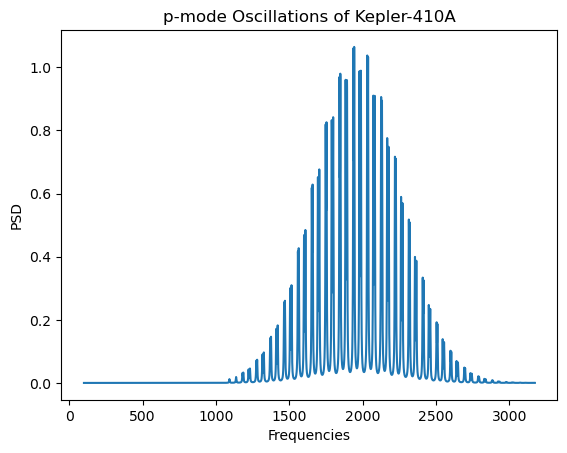

In [315]:
frequencies, powers = power_spec(mass, radius, teff, teff_sun)
plt.plot(frequencies, powers)
plt.xlabel("Frequencies")
plt.ylabel("PSD")
plt.title("p-mode Oscillations of Kepler-410A")
plt.show()

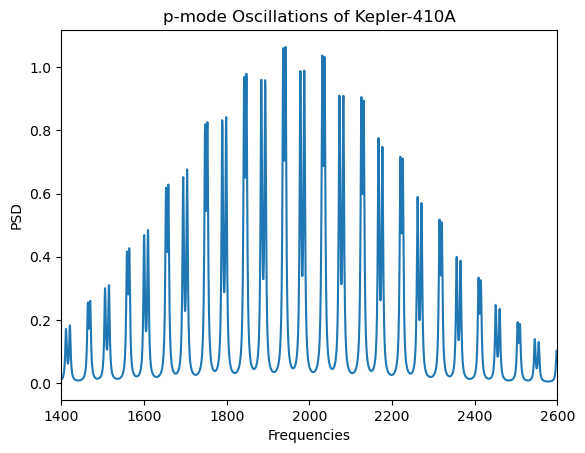

In [316]:
frequencies, powers = power_spec(mass, radius, teff, teff_sun)
plt.plot(frequencies, powers)
plt.xlabel("Frequencies")
plt.ylabel("PSD")
plt.title("p-mode Oscillations of Kepler-410A")
plt.xlim(1400,2600)
plt.show()